### Task 1: Dataset Preparation

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
from torchinfo import summary
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [4]:
transform = transforms.ToTensor()
torch.manual_seed(42)

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=generator
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 626kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.00MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.3MB/s]


Train: 54000
Val: 6000
Test: 10000


### Task 2: CNN Model

In [5]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64*5*5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [6]:
model = CNNModel().to(device)
print(model)

summary(model, input_size=(1, 1, 28, 28))

CNNModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
CNNModel                                 [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─MaxPool2d: 1-2                         [1, 32, 13, 13]           --
├─Conv2d: 1-3                            [1, 64, 11, 11]           18,496
├─MaxPool2d: 1-4                         [1, 64, 5, 5]             --
├─Linear: 1-5                            [1, 128]                  204,928
├─Linear: 1-6                            [1, 10]                   1,290
Total params: 225,034
Trainable params: 225,034
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.66
Input size (MB): 0.00
Forward/backward pass size (MB): 0.24
Params size (MB): 0.90
Estimated Total Size (MB): 1.14

### Task 3: Training

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs=10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"\nEpoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

torch.save(model.state_dict(), "cnn_mnist.pth")
print("\nModel saved as cnn_mnist.pth")


Epoch [1/10]
Train Loss: 0.2125 | Train Acc: 93.66%
Val Loss:   0.0785 | Val Acc:   97.68%

Epoch [2/10]
Train Loss: 0.0599 | Train Acc: 98.11%
Val Loss:   0.0641 | Val Acc:   97.97%

Epoch [3/10]
Train Loss: 0.0397 | Train Acc: 98.76%
Val Loss:   0.0441 | Val Acc:   98.70%

Epoch [4/10]
Train Loss: 0.0310 | Train Acc: 99.03%
Val Loss:   0.0451 | Val Acc:   98.80%

Epoch [5/10]
Train Loss: 0.0239 | Train Acc: 99.24%
Val Loss:   0.0466 | Val Acc:   98.67%

Epoch [6/10]
Train Loss: 0.0192 | Train Acc: 99.39%
Val Loss:   0.0370 | Val Acc:   98.98%

Epoch [7/10]
Train Loss: 0.0147 | Train Acc: 99.50%
Val Loss:   0.0549 | Val Acc:   98.68%

Epoch [8/10]
Train Loss: 0.0111 | Train Acc: 99.66%
Val Loss:   0.0457 | Val Acc:   98.75%

Epoch [9/10]
Train Loss: 0.0089 | Train Acc: 99.71%
Val Loss:   0.0485 | Val Acc:   98.95%

Epoch [10/10]
Train Loss: 0.0087 | Train Acc: 99.72%
Val Loss:   0.0451 | Val Acc:   98.97%

Model saved as cnn_mnist.pth


### Task 4: Evaluation and Visualization

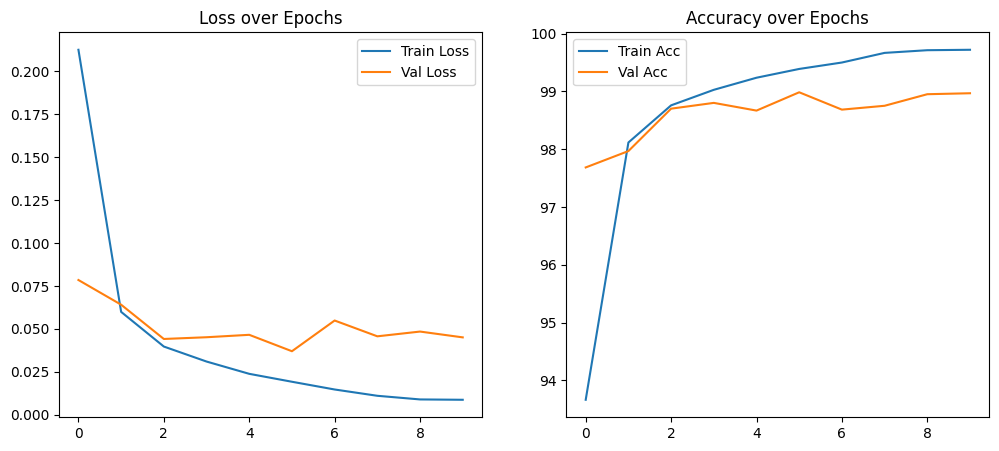

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(val_accuracies, label="Val Acc")
plt.title("Accuracy over Epochs")
plt.legend()
plt.show()

In [9]:
# model=model.to(device)
model.eval()

correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.tolist())
        all_labels.extend(labels.tolist())

print("\nTest Accuracy:", 100 * correct / total)


Test Accuracy: 99.12



Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.98      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



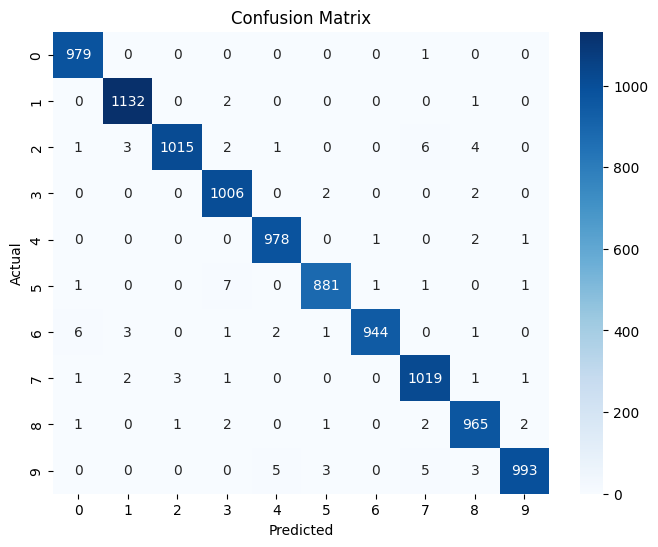

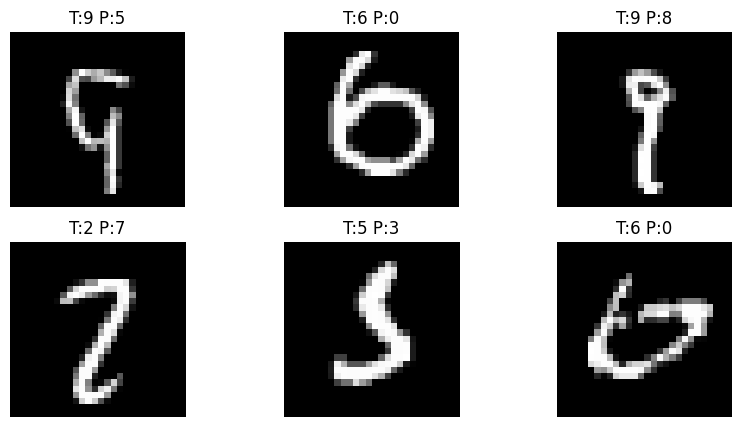

In [10]:
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

mis_images = []
mis_labels = []
mis_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                mis_images.append(images[i])
                mis_labels.append(labels[i])
                mis_preds.append(predicted[i])

        if len(mis_images) >= 6:
            break

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(mis_images[i].cpu().squeeze(), cmap="gray")
    plt.title(f"T:{mis_labels[i].item()} P:{mis_preds[i].item()}")
    plt.axis("off")

plt.show()

### Task 5: Experimentation and Analysis

In [11]:
class CNNModelDynamic(nn.Module):
    def __init__(
        self,
        num_conv_layers=2,
        filters=[32, 64],
        activation="relu",
        use_dropout=False
    ):
        super().__init__()

        self.use_dropout = use_dropout

        conv_layers = []
        in_channels = 1

        for i in range(num_conv_layers):
            out_channels = filters[i] if i < len(filters) else filters[-1]

            conv_layers.append(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
            )
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.MaxPool2d(2))

            in_channels = out_channels

        self.conv_block = nn.Sequential(*conv_layers)

        if activation == "relu":
            self.act = nn.ReLU()
        elif activation == "leakyrelu":
            self.act = nn.LeakyReLU(0.01)
        else:
            self.act = nn.ReLU()

        self.dropout = nn.Dropout(0.5)

        self._to_linear = None
        self._get_flatten_size()

        self.fc1 = nn.Linear(self._to_linear, 128)
        self.fc2 = nn.Linear(128, 10)

    def _get_flatten_size(self):
        with torch.no_grad():
            x = torch.zeros(1, 1, 28, 28)
            x = self.conv_block(x)
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)

        if self.use_dropout:
            x = self.dropout(x)

        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x

In [12]:
def train_and_validate(model, train_loader, val_loader, lr, epochs=3, device="cpu"):
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

### Architecture Comparison

In [29]:
configs_arch = [
    {"num_conv_layers": 2, "filters": [32, 64], "activation": "relu"},
    {"num_conv_layers": 2, "filters": [32, 64], "activation": "leakyrelu"},
    {"num_conv_layers": 3, "filters": [32, 64, 128], "activation": "relu"},
    {"num_conv_layers": 3, "filters": [32, 64, 128], "activation": "leakyrelu"},
]

arch_results = []

for i, cfg in enumerate(configs_arch):
    print(f"\n🔹 Architecture Experiment {i+1}")
    print(cfg)

    model_arch = CNNModelDynamic(
        num_conv_layers=cfg["num_conv_layers"],
        filters=cfg["filters"],
        activation=cfg["activation"],
        use_dropout=False
    )

    val_acc = train_and_validate(
        model_arch,
        train_loader,
        val_loader,
        lr=0.001,
        epochs=5,
        device=device
    )

    arch_results.append((cfg, val_acc))
    print(f"Validation Accuracy: {val_acc:.2f}%")

print("\nArchitecture Comparison Results:")
for cfg, acc in arch_results:
    print(cfg, "→", f"{acc:.2f}%")


🔹 Architecture Experiment 1
{'num_conv_layers': 2, 'filters': [32, 64], 'activation': 'relu'}
Validation Accuracy: 98.83%

🔹 Architecture Experiment 2
{'num_conv_layers': 2, 'filters': [32, 64], 'activation': 'leakyrelu'}
Validation Accuracy: 98.57%

🔹 Architecture Experiment 3
{'num_conv_layers': 3, 'filters': [32, 64, 128], 'activation': 'relu'}
Validation Accuracy: 99.00%

🔹 Architecture Experiment 4
{'num_conv_layers': 3, 'filters': [32, 64, 128], 'activation': 'leakyrelu'}
Validation Accuracy: 98.92%

Architecture Comparison Results:
{'num_conv_layers': 2, 'filters': [32, 64], 'activation': 'relu'} → 98.83%
{'num_conv_layers': 2, 'filters': [32, 64], 'activation': 'leakyrelu'} → 98.57%
{'num_conv_layers': 3, 'filters': [32, 64, 128], 'activation': 'relu'} → 99.00%
{'num_conv_layers': 3, 'filters': [32, 64, 128], 'activation': 'leakyrelu'} → 98.92%


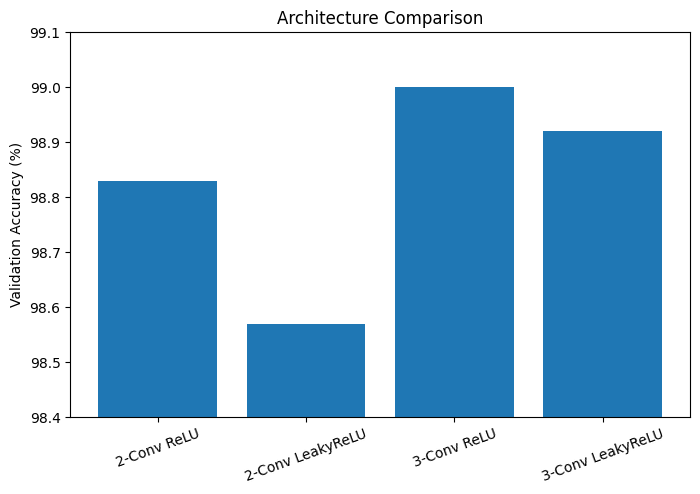

In [34]:
labels = [
    "2-Conv ReLU",
    "2-Conv LeakyReLU",
    "3-Conv ReLU",
    "3-Conv LeakyReLU"
]

accuracies = [98.83, 98.57, 99.00, 98.92]

plt.figure(figsize=(8,5))
plt.bar(labels, accuracies)

plt.ylabel("Validation Accuracy (%)")
plt.title("Architecture Comparison")
plt.ylim(98.4, 99.1)

plt.xticks(rotation=20)
plt.show()

### Overfitting Analysis with and without dropout

Epoch 1: Train 94.22% | Val 97.98%
Epoch 2: Train 98.40% | Val 98.12%
Epoch 3: Train 98.87% | Val 98.70%
Epoch 4: Train 99.12% | Val 98.62%
Epoch 5: Train 99.32% | Val 98.90%
Epoch 6: Train 99.44% | Val 98.98%
Epoch 7: Train 99.58% | Val 98.88%
Epoch 8: Train 99.63% | Val 98.55%
Epoch 9: Train 99.69% | Val 98.68%
Epoch 10: Train 99.73% | Val 99.07%
Epoch 1: Train 93.53% | Val 97.62%
Epoch 2: Train 97.69% | Val 98.48%
Epoch 3: Train 98.23% | Val 98.77%
Epoch 4: Train 98.61% | Val 98.88%
Epoch 5: Train 98.74% | Val 98.58%
Epoch 6: Train 98.95% | Val 98.87%
Epoch 7: Train 99.04% | Val 98.98%
Epoch 8: Train 99.12% | Val 99.08%
Epoch 9: Train 99.27% | Val 99.12%
Epoch 10: Train 99.31% | Val 99.13%


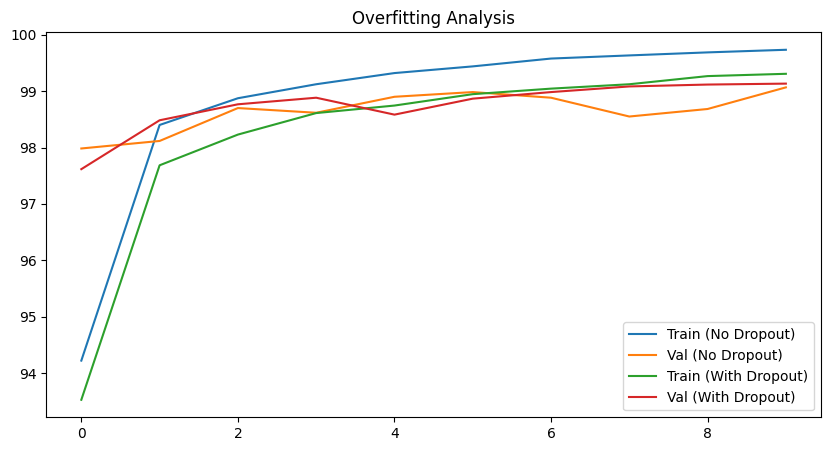

In [14]:
def train_full_tracking(model, train_loader, val_loader, epochs=10):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()

        train_acc = 100 * correct / total
        train_accs.append(train_acc)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, pred = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (pred == labels).sum().item()

        val_acc = 100 * correct / total
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train {train_acc:.2f}% | Val {val_acc:.2f}%")

    return train_accs, val_accs


model_no_dropout = CNNModelDynamic(use_dropout=False)
train_no, val_no = train_full_tracking(
    model_no_dropout, train_loader, val_loader, epochs=10
)

model_with_dropout = CNNModelDynamic(use_dropout=True)
train_do, val_do = train_full_tracking(
    model_with_dropout, train_loader, val_loader, epochs=10
)

plt.figure(figsize=(10,5))
plt.plot(train_no, label="Train (No Dropout)")
plt.plot(val_no, label="Val (No Dropout)")
plt.plot(train_do, label="Train (With Dropout)")
plt.plot(val_do, label="Val (With Dropout)")
plt.title("Overfitting Analysis")
plt.legend()
plt.show()

In [15]:
import random

search_space = {
    "batch_size": [32, 64, 128],
    "lr": [0.001, 0.0005, 0.0001],
    "num_conv_layers": [2, 3, 4],
    "filters": [
        [32, 64],
        [32, 64, 128],
        [64, 128]
    ],
    "activation": ["relu", "leakyrelu"],
    "use_dropout": [True, False]
}


In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

results = []
num_trials = 15

for trial in range(num_trials):

    config = {
        "batch_size": random.choice(search_space["batch_size"]),
        "lr": random.choice(search_space["lr"]),
        "num_conv_layers": random.choice(search_space["num_conv_layers"]),
        "filters": random.choice(search_space["filters"]),
        "activation": random.choice(search_space["activation"]),
        "use_dropout": random.choice(search_space["use_dropout"]),
    }

    print(f"\nTrial {trial+1}/{num_trials}")
    print(config)

    train_loader_search = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True
    )

    val_loader_search = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False
    )

    model_search = CNNModelDynamic(
        num_conv_layers=config["num_conv_layers"],
        filters=config["filters"],
        activation=config["activation"],
        use_dropout=config["use_dropout"]
    )

    val_acc = train_and_validate(
        model_search,
        train_loader_search,
        val_loader_search,
        lr=config["lr"],
        epochs=3,
        device=device
    )

    print(f"Validation Accuracy: {val_acc:.2f}%")

    results.append({
        "config": config,
        "val_acc": val_acc
    })

Using device: cuda

Trial 1/15
{'batch_size': 32, 'lr': 0.0001, 'num_conv_layers': 4, 'filters': [64, 128], 'activation': 'leakyrelu', 'use_dropout': False}
Validation Accuracy: 98.23%

Trial 2/15
{'batch_size': 32, 'lr': 0.0005, 'num_conv_layers': 2, 'filters': [32, 64], 'activation': 'relu', 'use_dropout': False}
Validation Accuracy: 98.40%

Trial 3/15
{'batch_size': 128, 'lr': 0.001, 'num_conv_layers': 3, 'filters': [32, 64], 'activation': 'relu', 'use_dropout': True}
Validation Accuracy: 98.63%

Trial 4/15
{'batch_size': 128, 'lr': 0.001, 'num_conv_layers': 2, 'filters': [64, 128], 'activation': 'leakyrelu', 'use_dropout': True}
Validation Accuracy: 98.38%

Trial 5/15
{'batch_size': 64, 'lr': 0.0005, 'num_conv_layers': 4, 'filters': [32, 64], 'activation': 'relu', 'use_dropout': True}
Validation Accuracy: 97.87%

Trial 6/15
{'batch_size': 128, 'lr': 0.001, 'num_conv_layers': 4, 'filters': [64, 128], 'activation': 'leakyrelu', 'use_dropout': False}
Validation Accuracy: 98.60%

Trial

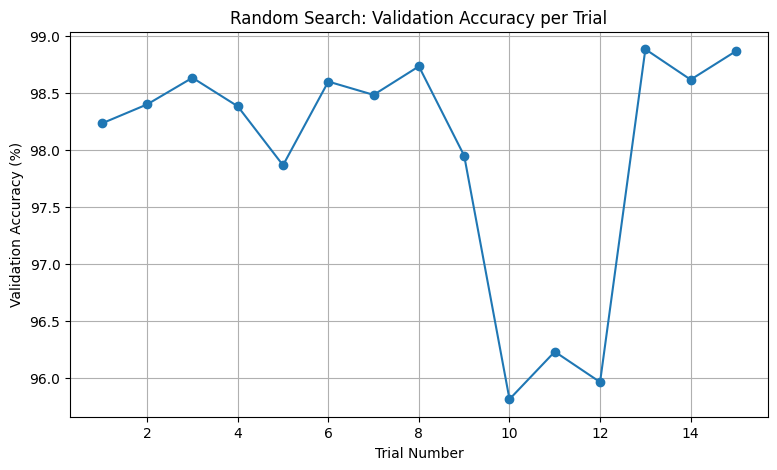

In [35]:
trial_nums = list(range(1, len(results) + 1))
val_accs = [r["val_acc"] for r in results]

plt.figure(figsize=(9,5))
plt.plot(trial_nums, val_accs, marker='o')
plt.xlabel("Trial Number")
plt.ylabel("Validation Accuracy (%)")
plt.title("Random Search: Validation Accuracy per Trial")
plt.grid(True)
plt.show()

In [31]:
best_result = max(results, key=lambda x: x["val_acc"])

print("\nBest Configuration found:")
print(best_result["config"])
print(f"Best Validation Accuracy: {best_result['val_acc']:.2f}%")

import pandas as pd

df_results = pd.DataFrame([
    {**r["config"], "val_acc": r["val_acc"]}
    for r in results
])

print("\nAll Trials:")
print(df_results.sort_values("val_acc", ascending=False))


Best Configuration found:
{'batch_size': 64, 'lr': 0.001, 'num_conv_layers': 2, 'filters': [64, 128], 'activation': 'relu', 'use_dropout': True}
Best Validation Accuracy: 98.88%

All Trials:
    batch_size      lr  num_conv_layers        filters activation  \
12          64  0.0010                2      [64, 128]       relu   
14          64  0.0010                3      [64, 128]       relu   
7          128  0.0010                2      [64, 128]  leakyrelu   
2          128  0.0010                3       [32, 64]       relu   
13          64  0.0010                2      [64, 128]       relu   
5          128  0.0010                4      [64, 128]  leakyrelu   
6           32  0.0005                2  [32, 64, 128]       relu   
1           32  0.0005                2       [32, 64]       relu   
3          128  0.0010                2      [64, 128]  leakyrelu   
0           32  0.0001                4      [64, 128]  leakyrelu   
8           32  0.0001                2      [64,

In [32]:

best_cfg = best_result["config"]

print("\nRetraining best configuration for full epochs...")

best_model = CNNModelDynamic(
    num_conv_layers=best_cfg["num_conv_layers"],
    filters=best_cfg["filters"],
    activation=best_cfg["activation"],
    use_dropout=best_cfg["use_dropout"]
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(best_model.parameters(), lr=best_cfg["lr"])

epochs_final = 10

for epoch in range(epochs_final):
    best_model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = best_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} completed")

best_model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, pred = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (pred == labels).sum().item()

print(f"\nFINAL TEST ACCURACY: {100 * correct / total:.2f}%")


Retraining best configuration for full epochs...
Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed

FINAL TEST ACCURACY: 99.23%


### Additional Questions

In [19]:
two_classes = [3, 8]

train_idx_2cls = [i for i, (_, y) in enumerate(train_dataset) if y in two_classes]
test_idx_2cls = [i for i, (_, y) in enumerate(test_dataset) if y in two_classes]

train_2cls = torch.utils.data.Subset(train_dataset, train_idx_2cls)
test_2cls = torch.utils.data.Subset(test_dataset, test_idx_2cls)

print("Train 2-class size:", len(train_2cls))
print("Test 2-class size:", len(test_2cls))

train_loader_2cls = DataLoader(train_2cls, batch_size=64, shuffle=True)
test_loader_2cls = DataLoader(test_2cls, batch_size=64, shuffle=False)

Train 2-class size: 10763
Test 2-class size: 1984


In [20]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 16, kernel_size=3)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(16 * 13 * 13, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [25]:
small_model = SmallCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(small_model.parameters(), lr=0.001)

epochs_small = 5

for epoch in range(epochs_small):
    small_model.train()
    correct, total = 0, 0

    for images, labels in train_loader_2cls:
        images, labels = images.to(device), labels.to(device)

        # convert labels {3,8} → {0,1}
        labels = (labels == 8).long()

        outputs = small_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}: Train Acc = {acc:.2f}%")

Epoch 1: Train Acc = 95.02%
Epoch 2: Train Acc = 98.15%
Epoch 3: Train Acc = 98.74%
Epoch 4: Train Acc = 99.11%
Epoch 5: Train Acc = 99.34%


In [26]:
small_model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader_2cls:
        images, labels = images.to(device), labels.to(device)
        labels = (labels == 8).long()

        outputs = small_model(images)
        _, pred = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (pred == labels).sum().item()

print(f"\nTwo-Class Test Accuracy: {100 * correct / total:.2f}%")


Two-Class Test Accuracy: 99.45%


Average difference after pooling: 0.1090836301445961


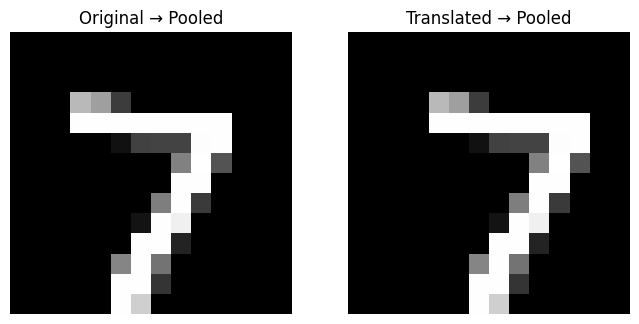

In [27]:

img, lbl = test_dataset[0]
img = img.unsqueeze(0).to(device)

img_translated = torch.roll(img, shifts=2, dims=3)

pool_demo = nn.MaxPool2d(kernel_size=2).to(device)

out_orig = pool_demo(img)
out_trans = pool_demo(img_translated)

diff = torch.abs(out_orig - out_trans).mean().item()
print("Average difference after pooling:", diff)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(out_orig.cpu().squeeze(), cmap="gray")
plt.title("Original → Pooled")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(out_trans.cpu().squeeze(), cmap="gray")
plt.title("Translated → Pooled")
plt.axis("off")

plt.show()

In [28]:
x_demo = torch.tensor(
    [[[[1., 2.],
       [3., 4.]]]],
    requires_grad=True,
    device=device
)
pool_back = nn.MaxPool2d(2)

y_demo = pool_back(x_demo)
print("Pooled output:", y_demo)
y_demo.backward(torch.ones_like(y_demo))

print("Gradient w.r.t input:\n", x_demo.grad)

Pooled output: tensor([[[[4.]]]], device='cuda:0', grad_fn=<MaxPool2DWithIndicesBackward0>)
Gradient w.r.t input:
 tensor([[[[0., 0.],
          [0., 1.]]]], device='cuda:0')
